# Báo cáo phân tích điểm thi THPT

## Hai phát hiện phía sau những con số

Một bảng điểm thường bắt đầu bằng câu hỏi “ai cao hơn?”. Nhưng khi nhìn kỹ hơn, dữ liệu cho thấy hai điểm đáng chú ý: khoảng cách giữa các vùng thực sự nằm ở môn nào, và cách đo lường có thể làm thay đổi kết luận ra sao.

### Phát hiện thứ nhất: khoảng cách không trải đều trên mọi môn

Ngoại ngữ là môn tạo ra khoảng cách lớn nhất về điểm trung bình, nhưng Ngữ văn lại dẫn đầu khi chỉ nhìn vào nhóm đạt từ 8 điểm. Cùng một bộ dữ liệu, hai cách nhìn cho hai điểm nhấn khác nhau.

### Phát hiện thứ hai: bảng xếp hạng có thể đổi chiều

Theo điểm thô, KHXH cao hơn trong 6/9 tổ hợp vùng–năm. Nhưng sau khi đặt từng môn về cùng một mặt bằng so sánh, KHTN lại cao hơn trong cả 9/9 tổ hợp.

### Thông điệp chính

**Muốn hiểu đúng kết quả thi, không nên chỉ hỏi ai cao hơn. Cần hỏi khoảng cách nằm ở môn nào, xuất hiện ở nhóm điểm nào và có thay đổi khi đổi thước đo hay không.**


## Mục tiêu và phạm vi

### Mục tiêu

Báo cáo được xây dựng như một cuộc đi tìm lời giải cho hai câu hỏi thực tế:

1. Khoảng cách giữa Bắc, Trung và Nam bắt nguồn từ môn nào?
2. KHTN hay KHXH có lợi thế hơn nếu chúng ta phân biệt điểm gốc với vị trí tương đối?

Vì vậy, mục tiêu không phải tạo ra một bảng xếp hạng đơn giản. Mục tiêu là lần theo cấu trúc phía sau con số: vùng nào mạnh ở môn nào, sự khác biệt nằm ở mặt bằng chung hay ở nhóm dẫn đầu, và kết luận có phụ thuộc vào cách tính hay không.

### Phạm vi dữ liệu

| Hạng mục | Phạm vi |
|---|---|
| Chương trình | CT2006 |
| Năm | 2022–2024 |
| Phân tích vùng | Bắc, Trung, Nam; 9 môn thi |
| Phân tích ban | Thí sinh có đủ 5 môn lõi của KHTN hoặc KHXH |
| Đơn vị so sánh | Năm, vùng, môn và ban |
| Dữ liệu thiếu | Giữ nguyên là thiếu, không thay bằng 0 |

### Cách đọc báo cáo

Mỗi câu hỏi đi qua cùng một hành trình: đặt vấn đề, giải thích vì sao vấn đề đáng quan tâm, mô tả cách đo lường, trình bày phát hiện, rồi kết thúc bằng câu trả lời và giới hạn diễn giải.


In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["svg.fonttype"] = "none"

candidates = [Path("data/processed/final_data.csv"), Path("../data/processed/final_data.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/processed/final_data.csv")

SUBJECTS = ["toan", "ngu_van", "ngoai_ngu", "vat_li", "hoa_hoc", "sinh_hoc", "lich_su", "dia_li", "gdcd"]
LABELS = {
    "toan": "Toán",
    "ngu_van": "Ngữ văn",
    "ngoai_ngu": "Ngoại ngữ",
    "vat_li": "Vật lí",
    "hoa_hoc": "Hóa học",
    "sinh_hoc": "Sinh học",
    "lich_su": "Lịch sử",
    "dia_li": "Địa lí",
    "gdcd": "GDCD",
}
SUBJECT_ORDER = SUBJECTS
REGION_ORDER = ["Bắc", "Trung", "Nam"]
USECOLS = ["nam", "chuong_trinh", "ban", "vung_3"] + SUBJECTS

# Thống kê theo năm–vùng–môn:
# số bài hợp lệ, tổng điểm, số điểm từ 8, số điểm dưới 5.
regional_stats = defaultdict(lambda: [0, 0.0, 0, 0])

# Histogram theo từng 0,01 điểm để tính trung vị mà không phải giữ toàn bộ dữ liệu trong bộ nhớ.
regional_hist = defaultdict(lambda: np.zeros(1001, dtype=np.int64))

# Tham số phân phối cấp quốc gia theo năm–môn: n, tổng điểm, tổng bình phương.
national = defaultdict(lambda: [0, 0.0, 0.0])

# Thống kê ban: số dòng, số dòng đủ 5 môn lõi, tổng điểm trung bình lõi,
# số dòng có điểm lõi TB từ 7 và từ 8.
ban_stats = defaultdict(lambda: [0, 0, 0.0, 0, 0])
ban_subject_sums = defaultdict(lambda: [0, 0.0])

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    chunksize=500_000,
    low_memory=False,
    dtype={"chuong_trinh": "string", "ban": "string"},
):
    d = chunk[
        (chunk["nam"].between(2022, 2024))
        & (chunk["chuong_trinh"] == "2006")
    ].copy()

    if d.empty:
        continue

    for col in SUBJECTS:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Phân tích khoảng cách vùng: mỗi môn dùng toàn bộ thí sinh có điểm hợp lệ ở môn đó.
    for (year, region), group in d.groupby(["nam", "vung_3"], sort=False):
        year, region = int(year), str(region)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue

            key = (year, region, col)
            item = regional_stats[key]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += int((values >= 8).sum())
            item[3] += int((values < 5).sum())

            rounded = np.clip(np.rint(values * 100).astype(int), 0, 1000)
            regional_hist[key] += np.bincount(rounded, minlength=1001)

    # Phân phối quốc gia dùng để chuẩn hóa điểm trong câu hỏi 2.
    for year, group in d.groupby("nam", sort=False):
        year = int(year)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            item = national[(year, col)]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += float((values * values).sum())

    # Phân tích KHTN–KHXH.
    for (year, region, ban), group in d[
        d["ban"].isin(["KHTN", "KHXH"])
    ].groupby(["nam", "vung_3", "ban"], sort=False):
        year, region, ban = int(year), str(region), str(ban)
        core_cols = (
            ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
            if ban == "KHTN"
            else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
        )
        core = group[core_cols].dropna()
        core_mean = core.mean(axis=1)
        key = (year, region, ban)
        item = ban_stats[key]
        item[0] += len(group)
        item[1] += len(core_mean)
        item[2] += float(core_mean.sum())
        item[3] += int((core_mean >= 7).sum())
        item[4] += int((core_mean >= 8).sum())

        for col in core_cols:
            item2 = ban_subject_sums[(key, col)]
            item2[0] += len(core)
            item2[1] += float(core[col].sum())

print(f"Đã đọc dữ liệu CT2006 2022–2024 từ: {DATA_PATH}")
print(f"Số nhóm năm–vùng–môn: {len(regional_stats)}")


Đã đọc dữ liệu CT2006 2022–2024; số nhóm năm–vùng–môn: 81


## 1. Khoảng cách điểm giữa Bắc, Trung và Nam bắt nguồn từ môn nào?

### Câu hỏi

Hãy bắt đầu từ một nhận xét rất quen thuộc: “vùng này có kết quả tốt hơn vùng kia”. Nhận xét đó có đúng ở tất cả các môn không, hay thực ra chỉ đến từ một vài môn? Và nếu nhìn riêng nhóm đạt điểm cao, kết luận có còn giống như khi nhìn điểm trung bình hay không?

### Vì sao cần phân tích?

Một điểm trung bình chung có thể làm cho nhiều khác biệt bị trộn lẫn. Vùng có lợi thế ở Toán chưa chắc có lợi thế ở Ngoại ngữ; vùng có mặt bằng ổn định chưa chắc có nhiều thí sinh ở nhóm dẫn đầu.

Tách kết quả theo từng môn giúp biến một nhận xét chung thành một câu trả lời có thể hành động: khoảng cách nằm ở đâu, vùng nào đang dẫn ở môn nào, và nên ưu tiên cải thiện mặt bằng chung hay mở rộng nhóm điểm cao.

### Phương pháp

- Phân tích 9 môn thi của CT2006 trong giai đoạn 2022–2024.
- Với mỗi năm, vùng và môn, tính điểm trung bình, trung vị và tỷ lệ đạt từ 8 điểm trở lên.
- Với từng môn, xác định khoảng cách giữa vùng cao nhất và vùng thấp nhất.
- Đọc kết quả theo hai lớp:
  - **Mặt bằng chung:** khoảng cách về điểm trung bình và trung vị.
  - **Nhóm dẫn đầu:** khoảng cách về tỷ lệ đạt từ 8 điểm.
- Chỉ sử dụng những bài thi có điểm hợp lệ ở môn đang phân tích; điểm thiếu không được quy đổi thành 0.


In [2]:
regional_rows = []
for (year, region, col), item in sorted(regional_stats.items()):
    n, total, ge8, lt5 = item
    cumulative = np.cumsum(regional_hist[(year, region, col)])
    middle_positions = [(n - 1) // 2, n // 2]
    middle_values = [
        np.searchsorted(cumulative, position + 1, side="left")
        for position in middle_positions
    ]
    median = float(np.mean(middle_values)) / 100

    regional_rows.append(
        {
            "Năm": year,
            "Vùng": region,
            "Môn": LABELS[col],
            "Môn_code": col,
            "Số bài hợp lệ": n,
            "Điểm trung bình": total / n,
            "Trung vị": median,
            "Từ 8 điểm (%)": 100 * ge8 / n,
            "Dưới 5 điểm (%)": 100 * lt5 / n,
        }
    )

regional_df = pd.DataFrame(regional_rows)
regional_df["Môn"] = pd.Categorical(
    regional_df["Môn"],
    categories=[LABELS[col] for col in SUBJECT_ORDER],
    ordered=True,
)
regional_df["Vùng"] = pd.Categorical(
    regional_df["Vùng"],
    categories=REGION_ORDER,
    ordered=True,
)

gap_rows = []
for (year, subject), group in regional_df.groupby(["Năm", "Môn"], observed=True):
    mean_high = group.loc[group["Điểm trung bình"].idxmax()]
    mean_low = group.loc[group["Điểm trung bình"].idxmin()]
    gap_rows.append(
        {
            "Năm": year,
            "Môn": subject,
            "Vùng cao nhất (TB)": mean_high["Vùng"],
            "Vùng thấp nhất (TB)": mean_low["Vùng"],
            "Khoảng cách TB (điểm)": mean_high["Điểm trung bình"] - mean_low["Điểm trung bình"],
            "Khoảng cách trung vị (điểm)": group["Trung vị"].max() - group["Trung vị"].min(),
            "Chênh lệch từ 8 (điểm %)": group["Từ 8 điểm (%)"].max() - group["Từ 8 điểm (%)"].min(),
        }
    )

gap_df = pd.DataFrame(gap_rows)
subject_summary = (
    gap_df.groupby("Môn", observed=True)
    .agg(
        {
            "Khoảng cách TB (điểm)": "mean",
            "Khoảng cách trung vị (điểm)": "mean",
            "Chênh lệch từ 8 (điểm %)": "mean",
        }
    )
    .reset_index()
    .sort_values("Khoảng cách TB (điểm)", ascending=False)
)

display(Markdown("### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn"))
display(
    gap_df[
        [
            "Năm",
            "Môn",
            "Vùng cao nhất (TB)",
            "Vùng thấp nhất (TB)",
            "Khoảng cách TB (điểm)",
            "Khoảng cách trung vị (điểm)",
            "Chênh lệch từ 8 (điểm %)",
        ]
    ].round(2)
)

display(Markdown("### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024"))
display(subject_summary.round(2))

display(Markdown(
    "Mỗi dòng cho biết khoảng cách giữa vùng có kết quả cao nhất và vùng có kết quả thấp nhất. "
    "Ví dụ, nếu **Chênh lệch từ 8 = 15 điểm %**, nghĩa là tỷ lệ thí sinh đạt từ 8 điểm "
    "ở hai vùng chênh nhau khoảng 15 điểm phần trăm."
))


### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn

 Năm       Môn Vùng cao nhất (TB) Vùng thấp nhất (TB)  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
2022      Toán                Nam               Trung                   0.30                         0.20                      4.98
2022   Ngữ văn                Bắc                 Nam                   0.32                         0.25                     13.10
2022 Ngoại ngữ                Nam               Trung                   0.61                         0.80                      5.31
2022    Vật lí                Bắc                 Nam                   0.55                         0.75                     17.01
2022   Hóa học                Bắc                 Nam                   0.29                         0.50                     12.31
2022  Sinh học                Nam               Trung                   0.21                         0.25                      0.47
2022   Lịch sử                Bắc               Trung                   0.36

### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024

      Môn  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
Ngoại ngữ                   0.56                         0.73                      5.66
   Vật lí                   0.53                         0.67                     15.69
  Ngữ văn                   0.37                         0.50                     16.00
     GDCD                   0.33                         0.33                     11.70
     Toán                   0.33                         0.20                      4.94
  Lịch sử                   0.28                         0.33                      5.40
 Sinh học                   0.22                         0.25                      1.37
   Địa lí                   0.22                         0.25                      4.66
  Hóa học                   0.19                         0.25                     10.00

Biểu đồ tĩnh được xuất trực tiếp từ component của ứng dụng dashboard.

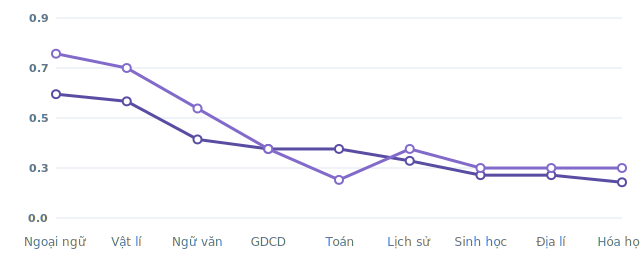

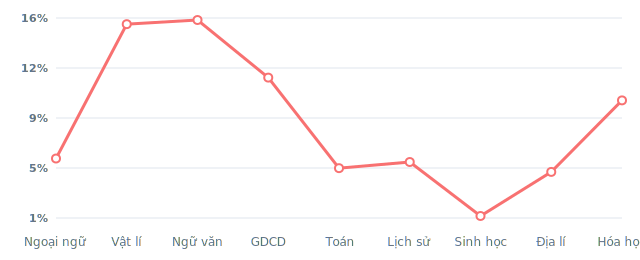

In [5]:
from IPython.display import Markdown, SVG, display
from pathlib import Path

ASSET_DIR = Path('../frontend/public/report')
display(Markdown('Biểu đồ tĩnh được xuất trực tiếp từ component của ứng dụng dashboard.'))
display(SVG(filename=str(ASSET_DIR / 'regional-1.svg')))
display(SVG(filename=str(ASSET_DIR / 'regional-2.svg')))


## Câu hỏi 1 — Kết quả và diễn giải

### Kết quả ở mặt bằng chung

- Xét điểm trung bình trong cả ba năm, **Ngoại ngữ có khoảng cách vùng lớn nhất**, khoảng **0,56 điểm** giữa vùng cao nhất và thấp nhất.
- **Vật lí** đứng ngay sau, với khoảng cách trung bình khoảng **0,53 điểm**.
- Vùng Trung có điểm trung bình thấp nhất ở **18/27 tổ hợp môn–năm**; tuy nhiên, không có vùng nào luôn đứng đầu ở mọi môn.

### Kết quả ở nhóm đạt điểm cao

Khi chuyển từ điểm trung bình sang tỷ lệ đạt từ 8 điểm trở lên, thứ hạng thay đổi. **Ngữ văn** trở thành môn có chênh lệch lớn nhất, khoảng **16 điểm phần trăm**; Vật lí đứng thứ hai với khoảng **15,7 điểm phần trăm**.

Điểm đáng chú ý là môn tạo ra khoảng cách lớn nhất ở mặt bằng chung không hoàn toàn trùng với môn tạo ra khoảng cách lớn nhất ở nhóm dẫn đầu.

### Trả lời

**Khoảng cách vùng miền không nằm ở một môn duy nhất. Ngoại ngữ là điểm nghẽn rõ nhất của mặt bằng chung, còn Ngữ văn cho thấy sự phân hóa rõ nhất ở nhóm đạt điểm cao.**

Nếu chỉ nhìn điểm trung bình, chúng ta sẽ ưu tiên Ngoại ngữ. Nếu quan tâm đến cơ hội tạo ra nhiều học sinh xuất sắc hơn, Ngữ văn và Vật lí mới là những môn cần được nhìn kỹ hơn. Vì vậy, câu hỏi “vùng nào học tốt hơn?” chỉ có ý nghĩa khi đi kèm tiêu chí cụ thể.

### Hàm ý

- Muốn cải thiện mặt bằng chung, nên ưu tiên phân tích sâu hơn Ngoại ngữ và Vật lí.
- Muốn mở rộng nhóm học sinh đạt thành tích cao, cần chú ý đến Ngữ văn và Vật lí.
- Dashboard nên đặt điểm trung bình, trung vị và tỷ lệ đạt ngưỡng cạnh nhau thay vì chỉ đưa ra một bảng xếp hạng vùng.
- Khuyến nghị cho từng vùng nên gắn với môn cụ thể, không nên gán một nhận xét chung cho toàn vùng.

### Giới hạn

Phân tích cho thấy sự khác biệt quan sát được giữa các vùng nhưng không xác định nguyên nhân của khác biệt đó. Kết quả có thể chịu ảnh hưởng của độ khó đề, lựa chọn môn thi, điều kiện học tập và thành phần thí sinh. Mỗi môn cũng có số lượng bài hợp lệ khác nhau; các chỉ số được tính trên chính số bài hợp lệ của môn đó.


## Câu hỏi 2 — Khi đổi thước đo, kết luận đổi chiều

### Câu hỏi

KHTN hay KHXH có kết quả tốt hơn? Câu hỏi tưởng như chỉ cần so sánh hai điểm trung bình. Nhưng nếu các môn thi có mặt bằng điểm rất khác nhau, liệu điểm gốc có đang phản ánh đúng năng lực tương đối?

### Vì sao cần phân tích?

Một ban có thể gồm những môn thường đạt điểm cao, trong khi ban kia gồm những môn có mặt bằng thấp hơn. Khi đó, điểm trung bình của ban không chỉ phản ánh kết quả của thí sinh; nó còn phản ánh cơ cấu môn thi.

Đây là lý do một bảng xếp hạng có thể đúng về số học nhưng chưa chắc trả lời đúng điều người đọc muốn biết: thí sinh đang có điểm cao hơn, hay đang đứng cao hơn so với những người thi cùng môn?

### Phương pháp

- KHTN gồm Toán, Ngữ văn, Vật lí, Hóa học và Sinh học.
- KHXH gồm Toán, Ngữ văn, Lịch sử, Địa lí và GDCD.
- Chỉ giữ những thí sinh có đủ 5 môn lõi của ban tương ứng.
- Tính hai chỉ số:
  - **Điểm thô:** trung bình của 5 điểm gốc.
  - **Điểm tương đối:** chuẩn hóa từng môn theo mặt bằng điểm của chính môn đó trong cùng năm, rồi lấy trung bình.
- So sánh hai ban trên 3 vùng trong 3 năm.


In [4]:
national_params = {}
for (year_col, item) in national.items():
    year, col = year_col
    n, total, sum_sq = item
    mean = total / n
    sd = np.sqrt(max(sum_sq / n - mean ** 2, 0))
    national_params[(year, col)] = (mean, sd)

ban_rows = []
for (year, region, ban), item in sorted(ban_stats.items()):
    total_ban, n_complete, raw_sum, ge7, ge8 = item
    if n_complete == 0:
        continue
    same_region = sum(ban_stats[(year, region, b)][0] for b in ["KHTN", "KHXH"])
    core_cols = (
        ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
        if ban == "KHTN"
        else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
    )
    z_means = []
    for col in core_cols:
        n_col, sum_col = ban_subject_sums[((year, region, ban), col)]
        mean, sd = national_params[(year, col)]
        z_means.append(((sum_col / n_col) - mean) / sd)
    ban_rows.append({
        "Năm": year,
        "Vùng": region,
        "Ban": ban,
        "Tỷ trọng trong vùng (%)": 100 * total_ban / same_region,
        "Đủ 5 môn lõi": n_complete,
        "Điểm thô TB": raw_sum / n_complete,
        "Điểm tương đối TB": float(np.mean(z_means)),
        "Lõi từ 7 (%)": 100 * ge7 / n_complete,
        "Lõi từ 8 (%)": 100 * ge8 / n_complete,
    })

ban_df = pd.DataFrame(ban_rows)
example = ban_df[(ban_df["Năm"] == 2022) & (ban_df["Vùng"] == "Bắc")][[
    "Ban", "Tỷ trọng trong vùng (%)", "Điểm thô TB", "Điểm tương đối TB", "Lõi từ 7 (%)"
]]
display(Markdown("### Ví dụ: Bắc năm 2022"))
display(example.round(2))

raw_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm thô TB")
relative_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm tương đối TB")
diff_df = pd.DataFrame({
    "Điểm thô: KHTN−KHXH": raw_pivot["KHTN"] - raw_pivot["KHXH"],
    "Điểm tương đối: KHTN−KHXH": relative_pivot["KHTN"] - relative_pivot["KHXH"],
}).reset_index()

display(Markdown("### Toàn bộ 9 tổ hợp vùng–năm"))
display(diff_df.round(3))
raw_wins = int((diff_df["Điểm thô: KHTN−KHXH"] > 0).sum())
relative_wins = int((diff_df["Điểm tương đối: KHTN−KHXH"] > 0).sum())
display(Markdown(
    f"**KHTN cao hơn theo điểm thô:** {raw_wins}/9 tổ hợp.  "
    f"**KHTN cao hơn sau chuẩn hóa:** {relative_wins}/9 tổ hợp."
))

### Ví dụ: Bắc năm 2022

 Ban  Tỷ trọng trong vùng (%)  Điểm thô TB  Điểm tương đối TB  Lõi từ 7 (%)
KHTN                    26.44         6.74               0.29         41.54
KHXH                    73.56         6.96               0.12         52.97

### Toàn bộ 9 tổ hợp vùng–năm

 Năm  Vùng  Điểm thô: KHTN−KHXH  Điểm tương đối: KHTN−KHXH
2022   Bắc               -0.218                      0.170
2022   Nam               -0.341                      0.095
2022 Trung               -0.061                      0.292
2023   Bắc                0.157                      0.176
2023   Nam                0.013                      0.087
2023 Trung                0.267                      0.264
2024   Bắc               -0.194                      0.153
2024   Nam               -0.326                      0.078
2024 Trung               -0.063                      0.264

**KHTN cao hơn theo điểm thô:** 3/9 tổ hợp.  **KHTN cao hơn sau chuẩn hóa:** 9/9 tổ hợp.

Biểu đồ tĩnh được xuất trực tiếp từ component của ứng dụng dashboard.

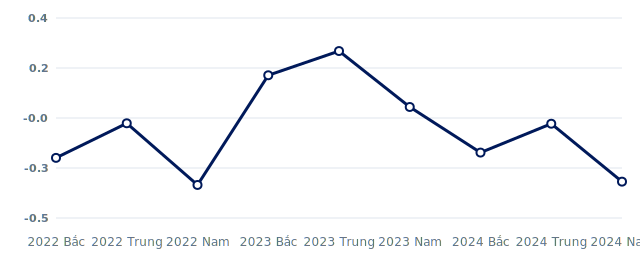

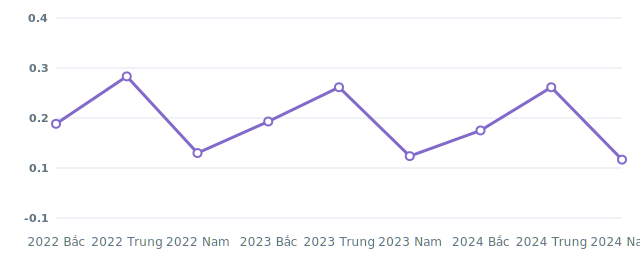

In [9]:
from IPython.display import Markdown, SVG, display
from pathlib import Path

ASSET_DIR = Path('../frontend/public/report')
display(Markdown('Biểu đồ tĩnh được xuất trực tiếp từ component của ứng dụng dashboard.'))
display(SVG(filename=str(ASSET_DIR / 'program-1.svg')))
display(SVG(filename=str(ASSET_DIR / 'program-2.svg')))


## Câu hỏi 2 — Kết quả và diễn giải

### Ví dụ minh họa: Bắc năm 2022

- Theo điểm gốc, KHXH đạt **6,96**, còn KHTN đạt **6,74**. Nếu dừng ở đây, chúng ta sẽ kết luận KHXH có lợi thế.
- Sau khi chuẩn hóa từng môn theo mặt bằng riêng, KHTN đạt khoảng **+0,29 độ lệch chuẩn**, còn KHXH đạt **+0,12**. Lợi thế lúc này chuyển sang KHTN.
- Trên 9 tổ hợp vùng–năm, KHTN cao hơn **3/9 lần theo điểm gốc**, nhưng cao hơn **9/9 lần theo điểm tương đối**.

### Trả lời

**Không có một ban luôn tốt hơn theo mọi cách đo. KHXH cao hơn khi xét điểm gốc, còn KHTN có lợi thế nhất quán khi xét vị trí tương đối so với mặt bằng của từng môn.**

Đây không phải là mâu thuẫn trong dữ liệu mà là một lời nhắc về cách đặt câu hỏi. Điểm thô trả lời “thí sinh nhận được bao nhiêu điểm”; điểm tương đối trả lời “thí sinh đứng ở đâu trong môn mình đã thi”. Hai câu hỏi khác nhau sẽ cần hai thước đo khác nhau.

### Hàm ý

Khi báo cáo hoặc xếp hạng KHTN và KHXH, nên đặt cạnh nhau:

1. điểm gốc, vì đây là điểm thí sinh thực sự nhận được;
2. điểm tương đối theo môn–năm, để so sánh vị trí công bằng hơn;
3. tỷ lệ đạt các ngưỡng điểm, vì chỉ số này gần với mục tiêu xét tuyển hơn.

Không nên biến kết quả thành kết luận “ban này dễ hơn” hoặc “ban kia giỏi hơn” nếu chưa tính đến cơ cấu môn thi, lựa chọn của thí sinh và mặt bằng điểm của từng môn.

### Giới hạn

Chuẩn hóa giúp phép so sánh hợp lý hơn về mặt thống kê nhưng không loại bỏ hoàn toàn khác biệt về lựa chọn môn, điều kiện học tập hay năng lực đầu vào. Vì vậy, kết quả nên được hiểu là lợi thế theo từng thước đo, không phải bằng chứng về quan hệ nhân quả.


## Tổng kết

### Hai phát hiện cần nhớ

1. **Khoảng cách vùng miền phụ thuộc vào môn và nhóm điểm được xét.** Ngoại ngữ tạo ra khác biệt lớn nhất về điểm trung bình, còn Ngữ văn tạo ra khác biệt lớn nhất ở nhóm đạt từ 8 điểm.
2. **Điểm gốc và điểm tương đối trả lời hai câu hỏi khác nhau.** KHXH cao hơn theo điểm gốc, trong khi KHTN cao hơn khi so sánh vị trí tương đối theo từng môn.